## Problem 3

In [ ]:
# === Environment & Utilities ===
import json
import math
from pathlib import Path
from typing import Dict, List

import matplotlib.pyplot as plt
import numpy as np
import tensorflow as tf
from tensorflow.keras import layers
from IPython.display import Image, display

AUTOTUNE = tf.data.AUTOTUNE


In [ ]:
# === Dataset preparation ===
def make_mnist_dataset(batch_size: int, buffer_size: int = 60000):
    """Load MNIST, scale to [-1, 1], and create a shuffled tf.data pipeline."""
    (x_train, _), _ = tf.keras.datasets.mnist.load_data()
    x_train = (x_train.astype("float32") / 127.5) - 1.0
    x_train = np.expand_dims(x_train, axis=-1)
    ds = tf.data.Dataset.from_tensor_slices(x_train)
    ds = ds.shuffle(buffer_size).batch(batch_size, drop_remainder=True)
    ds = ds.prefetch(AUTOTUNE)
    return ds


def get_mnist_dataset(batch_size: int = 64, shuffle_buffer: int = 60000):
    """Convenience wrapper used throughout the notebook."""
    return make_mnist_dataset(batch_size=batch_size, buffer_size=shuffle_buffer)



## Model Definitions
We build lightweight convolutional generator and critic networks with TensorFlow/Keras layers.

In [ ]:
# === Models ===
def build_generator(latent_dim: int, base_channels: int = 64):
    model = tf.keras.Sequential(
        [
            layers.Input(shape=(latent_dim,)),
            layers.Dense(7 * 7 * base_channels, use_bias=False),
            layers.BatchNormalization(),
            layers.ReLU(),
            layers.Reshape((7, 7, base_channels)),
            layers.Conv2DTranspose(base_channels // 2, 4, strides=2, padding="same", use_bias=False),
            layers.BatchNormalization(),
            layers.ReLU(),
            layers.Conv2DTranspose(base_channels // 4, 4, strides=2, padding="same", use_bias=False),
            layers.BatchNormalization(),
            layers.ReLU(),
            layers.Conv2D(1, 5, padding="same", activation="tanh"),
        ],
        name="generator",
    )
    return model



def build_discriminator(base_channels: int = 64):
    model = tf.keras.Sequential(
        [
            layers.Input(shape=(28, 28, 1)),
            layers.Conv2D(base_channels, 5, strides=2, padding="same"),
            layers.LeakyReLU(0.2),
            layers.Conv2D(base_channels * 2, 5, strides=2, padding="same"),
            layers.LayerNormalization(),
            layers.LeakyReLU(0.2),
            layers.Flatten(),
            layers.Dense(1),
        ],
        name="discriminator",
    )
    return model



def create_models(latent_dim: int = 128, base_channels: int = 96):
    generator = build_generator(latent_dim=latent_dim, base_channels=base_channels)
    discriminator = build_discriminator(base_channels=base_channels)
    return generator, discriminator


In [ ]:
# === Training Utils ===
def preview_batch(dataset, n: int = 16):
    batch = next(iter(dataset.unbatch().batch(n)))
    images = (batch.numpy() + 1.0) * 0.5
    rows = int(math.sqrt(n))
    cols = rows
    fig, axes = plt.subplots(rows, cols, figsize=(cols, rows))
    for ax, img in zip(axes.flatten(), images):
        ax.imshow(img.squeeze(), cmap='gray')
        ax.axis('off')
    plt.show()



def save_image_grid(generator, latent_dim: int, grid_size: int, out_path: Path):
    noise = tf.random.normal([grid_size ** 2, latent_dim])
    preds = generator(noise, training=False)
    preds = (preds + 1.0) * 0.5
    preds = tf.clip_by_value(preds, 0.0, 1.0)
    canvas = np.zeros((28 * grid_size, 28 * grid_size))
    imgs = preds.numpy().reshape(grid_size ** 2, 28, 28)
    for i in range(grid_size):
        for j in range(grid_size):
            canvas[i * 28:(i + 1) * 28, j * 28:(j + 1) * 28] = imgs[i * grid_size + j]
    plt.figure(figsize=(grid_size, grid_size))
    plt.imshow(canvas, cmap='gray')
    plt.axis('off')
    out_path = Path(out_path)
    out_path.parent.mkdir(parents=True, exist_ok=True)
    plt.savefig(out_path, bbox_inches='tight', pad_inches=0)
    plt.close()


In [ ]:
# === Core Trainers ===
class WGANGPTrainer:
    def __init__(
        self,
        latent_dim: int,
        batch_size: int,
        n_critic: int,
        gp_weight: float,
        gen: tf.keras.Model,
        disc: tf.keras.Model,
        g_opt: tf.keras.optimizers.Optimizer,
        d_opt: tf.keras.optimizers.Optimizer,
    ):
        self.latent_dim = latent_dim
        self.batch_size = batch_size
        self.n_critic = n_critic
        self.gp_weight = gp_weight
        self.generator = gen
        self.discriminator = disc
        self.g_opt = g_opt
        self.d_opt = d_opt

    def gradient_penalty(self, real_images, fake_images):
        epsilon = tf.random.uniform([self.batch_size, 1, 1, 1], 0.0, 1.0)
        interpolated = epsilon * real_images + (1.0 - epsilon) * fake_images
        with tf.GradientTape() as tape:
            tape.watch(interpolated)
            pred = self.discriminator(interpolated, training=True)
        grads = tape.gradient(pred, interpolated)
        grads = tf.reshape(grads, [self.batch_size, -1])
        slopes = tf.sqrt(tf.reduce_sum(tf.square(grads), axis=1) + 1e-12)
        return tf.reduce_mean((slopes - 1.0) ** 2)

    @tf.function
    def critic_train_step(self, real_images):
        noise = tf.random.normal([self.batch_size, self.latent_dim])
        with tf.GradientTape() as tape:
            fake_images = self.generator(noise, training=True)
            fake_images = tf.stop_gradient(fake_images)
            real_logits = self.discriminator(real_images, training=True)
            fake_logits = self.discriminator(fake_images, training=True)
            gp = tf.constant(0.0)
            if self.gp_weight > 0:
                gp = self.gradient_penalty(real_images, fake_images)
            d_loss = tf.reduce_mean(fake_logits) - tf.reduce_mean(real_logits) + self.gp_weight * gp
        d_grads = tape.gradient(d_loss, self.discriminator.trainable_variables)
        self.d_opt.apply_gradients(zip(d_grads, self.discriminator.trainable_variables))
        wasserstein = tf.reduce_mean(real_logits) - tf.reduce_mean(fake_logits)
        return d_loss, wasserstein

    @tf.function
    def generator_train_step(self):
        noise = tf.random.normal([self.batch_size, self.latent_dim])
        with tf.GradientTape() as tape:
            fake_images = self.generator(noise, training=True)
            fake_logits = self.discriminator(fake_images, training=True)
            g_loss = -tf.reduce_mean(fake_logits)
        g_grads = tape.gradient(g_loss, self.generator.trainable_variables)
        self.g_opt.apply_gradients(zip(g_grads, self.generator.trainable_variables))
        return g_loss

    def sample_images(self, num_samples: int, out_path: Path):
        noise = tf.random.normal([num_samples, self.latent_dim])
        generated = self.generator(noise, training=False)
        generated = (generated + 1.0) * 0.5
        generated = tf.clip_by_value(generated, 0.0, 1.0)
        n = int(math.sqrt(num_samples))
        canvas = np.zeros((28 * n, 28 * n))
        imgs = generated.numpy().reshape(num_samples, 28, 28)
        for i in range(n):
            for j in range(n):
                canvas[i * 28 : (i + 1) * 28, j * 28 : (j + 1) * 28] = imgs[i * n + j]
        plt.figure(figsize=(n, n))
        plt.axis("off")
        plt.imshow(canvas, cmap="gray")
        out_path = Path(out_path)
        out_path.parent.mkdir(parents=True, exist_ok=True)
        plt.savefig(out_path, bbox_inches="tight", pad_inches=0)
        plt.close()


class NotebookTrainer:
    def __init__(
        self,
        generator: tf.keras.Model,
        discriminator: tf.keras.Model,
        dataset: tf.data.Dataset,
        batch_size: int,
        latent_dim: int = 128,
        n_critic: int = 3,
        gp_weight: float = 10.0,
        lr: float = 2e-4,
        beta1: float = 0.0,
        beta2: float = 0.99,
        output_dir: str = "outputs/notebook_run",
        sample_every: int = 5,
        sample_grid: int = 6,
        max_batches: int = 0,
        eager: bool = False,
    ):
        if eager:
            tf.config.run_functions_eagerly(True)
        self.dataset = dataset
        self.batch_size = batch_size
        self.latent_dim = latent_dim
        self.sample_every = sample_every
        self.sample_grid = sample_grid
        self.max_batches = max_batches
        self.output_dir = Path(output_dir)
        self.output_dir.mkdir(parents=True, exist_ok=True)

        g_opt = tf.keras.optimizers.Adam(lr, beta_1=beta1, beta_2=beta2)
        d_opt = tf.keras.optimizers.Adam(lr, beta_1=beta1, beta_2=beta2)

        self.trainer = WGANGPTrainer(
            latent_dim,
            batch_size,
            n_critic,
            gp_weight,
            generator,
            discriminator,
            g_opt,
            d_opt,
        )
        self.history: Dict[str, List[float]] = {"g_loss": [], "d_loss": [], "wasserstein": []}
        self.config = dict(
            latent_dim=latent_dim,
            n_critic=n_critic,
            gp_weight=gp_weight,
            lr=lr,
            beta1=beta1,
            beta2=beta2,
            batch_size=batch_size,
            sample_every=sample_every,
            sample_grid=sample_grid,
            max_batches=max_batches,
            output_dir=output_dir,
        )

    def train(self, epochs: int):
        for epoch in range(1, epochs + 1):
            g_epoch, d_epoch, w_epoch = [], [], []
            for step, real_images in enumerate(self.dataset):
                for _ in range(self.trainer.n_critic):
                    d_loss, w_dist = self.trainer.critic_train_step(real_images)
                    d_epoch.append(float(d_loss.numpy()))
                    w_epoch.append(float(w_dist.numpy()))
                g_loss = self.trainer.generator_train_step()
                g_epoch.append(float(g_loss.numpy()))
                if self.max_batches and (step + 1) >= self.max_batches:
                    break
            self.history['g_loss'].append(float(np.mean(g_epoch)))
            self.history['d_loss'].append(float(np.mean(d_epoch)))
            self.history['wasserstein'].append(float(np.mean(w_epoch)))
            if self.sample_every and (epoch % self.sample_every == 0 or epoch == epochs):
                save_image_grid(
                    self.trainer.generator,
                    self.latent_dim,
                    self.sample_grid,
                    Path(self.output_dir) / f"samples_epoch_{epoch:03d}.png",
                )
            print(
                f"Epoch {epoch}/{epochs} | G loss: {self.history['g_loss'][-1]:.4f} "
                f"| D loss: {self.history['d_loss'][-1]:.4f} | W-dist: {self.history['wasserstein'][-1]:.4f}"
            )
        with open(self.output_dir / "history.json", "w") as f:
            json.dump(self.history, f, indent=2)
        with open(self.output_dir / "config.json", "w") as f:
            json.dump(self.config | {"epochs": epochs}, f, indent=2)
        save_image_grid(self.trainer.generator, self.latent_dim, self.sample_grid, self.output_dir / "final_samples.png")
        return self.history


In [ ]:
# === History & Reporting Helpers ===
def load_history(path: Path):
    with open(path) as f:
        return json.load(f)


def plot_history(history, title: str = "WGAN-GP Training Curves", out_path: Path | None = None):
    epochs = range(1, len(history["g_loss"]) + 1)
    plt.figure(figsize=(8, 5))
    plt.plot(epochs, history["g_loss"], label="Generator loss")
    plt.plot(epochs, history["d_loss"], label="Critic loss")
    plt.plot(epochs, history["wasserstein"], label="Wasserstein estimate")
    plt.xlabel("Epoch")
    plt.ylabel("Loss")
    plt.title(title)
    plt.legend()
    plt.grid(True, alpha=0.3)
    if out_path is not None:
        out_path = Path(out_path)
        out_path.parent.mkdir(parents=True, exist_ok=True)
        plt.savefig(out_path, bbox_inches="tight")
    plt.show()


In [ ]:
# === Notebook Experiment Runner ===
def run_notebook_experiment(config: Dict, title: str):
    print('Configuration:')
    print(json.dumps(config, indent=2))
    dataset = get_mnist_dataset(batch_size=config['batch_size'])
    generator, discriminator = create_models(
        latent_dim=config['latent_dim'],
        base_channels=config['base_channels'],
    )
    trainer = NotebookTrainer(
        generator,
        discriminator,
        dataset,
        batch_size=config['batch_size'],
        latent_dim=config['latent_dim'],
        n_critic=config['n_critic'],
        gp_weight=config['gp_weight'],
        lr=config['lr'],
        beta1=config['beta1'],
        beta2=config['beta2'],
        output_dir=config['output_dir'],
        sample_every=config['sample_every'],
        sample_grid=config['sample_grid'],
        max_batches=config.get('max_batches', 0),
        eager=config.get('eager', False),
    )
    history = trainer.train(config['epochs'])
    history_path = Path(config['output_dir']) / 'history.png'
    plot_history(history, title=title, out_path=history_path)
    if history_path.exists():
        print(f'Saved training curves to {history_path}')
    samples_path = Path(config['output_dir']) / 'final_samples.png'
    if samples_path.exists():
        display(Image(filename=str(samples_path)))
        print(f'Saved sample grid to {samples_path}')
    else:
        print(f'Expected samples at {samples_path} but file was not found.')
    return history


11490434/11490434 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


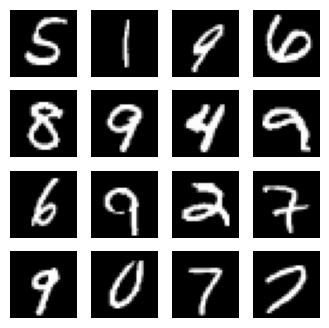

In [ ]:
# === Quick Preview ===
train_dataset = get_mnist_dataset(batch_size=64)
preview_batch(train_dataset, n=16)


Configuration:
{
  "latent_dim": 128,
  "batch_size": 64,
  "n_critic": 3,
  "gp_weight": 10.0,
  "lr": 0.0002,
  "beta1": 0.0,
  "beta2": 0.99,
  "epochs": 20,
  "base_channels": 96,
  "seed": 1234,
  "output_dir": "outputs/wgan_gp_baseline",
  "sample_every": 5,
  "sample_grid": 6,
  "max_batches": 5,
  "log_interval": 5,
  "eager": true
}
Epoch 1/20 | G loss: 14.8456 | D loss: -24.6907 | W-dist: 29.2647
Epoch 2/20 | G loss: 19.1826 | D loss: -38.1119 | W-dist: 47.2910
Epoch 3/20 | G loss: 19.7268 | D loss: -37.7270 | W-dist: 48.3969
Epoch 4/20 | G loss: 22.2879 | D loss: -39.1086 | W-dist: 51.2519
Epoch 5/20 | G loss: 22.4508 | D loss: -39.4057 | W-dist: 52.9127
Epoch 6/20 | G loss: 19.0189 | D loss: -35.4356 | W-dist: 47.2830
Epoch 7/20 | G loss: 21.1698 | D loss: -35.5461 | W-dist: 47.8034
Epoch 8/20 | G loss: 21.6916 | D loss: -33.5996 | W-dist: 45.4917
Epoch 9/20 | G loss: 12.3001 | D loss: -23.6935 | W-dist: 31.0037
Epoch 10/20 | G loss: 11.0547 | D loss: -22.0118 | W-dist: 28.

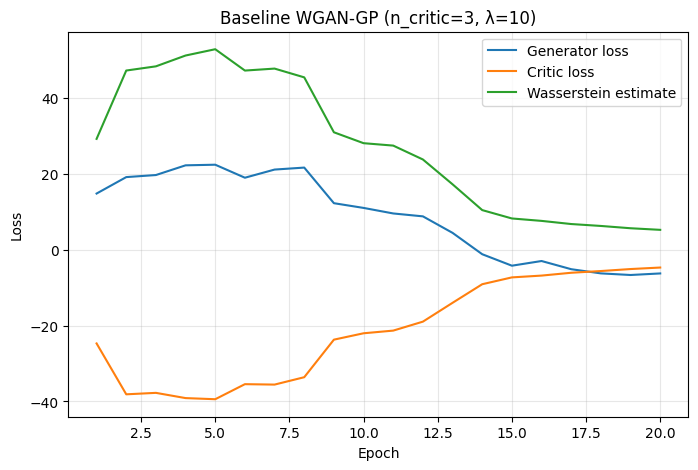

Saved training curves to outputs/wgan_gp_baseline/history.png


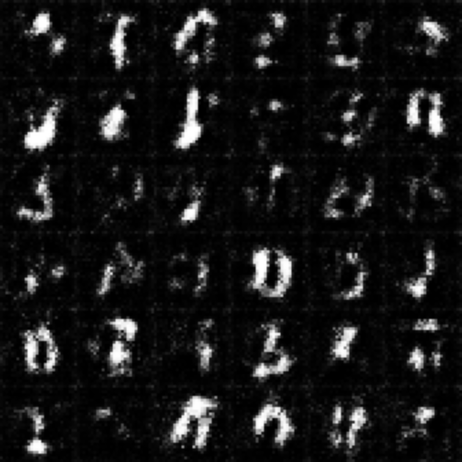

Saved sample grid to outputs/wgan_gp_baseline/final_samples.png


{'g_loss': [14.845597267150879,
  19.18261299133301,
  19.726774597167967,
  22.28791923522949,
  22.45083236694336,
  19.01890640258789,
  21.16978759765625,
  21.691624259948732,
  12.300076103210449,
  11.054721355438232,
  9.591865825653077,
  8.828117752075196,
  4.472149565815926,
  -1.1614201307296752,
  -4.185015487670898,
  -2.951010012626648,
  -5.1112597465515135,
  -6.215145778656006,
  -6.638625907897949,
  -6.228333616256714],
 'd_loss': [-24.690652243296306,
  -38.11185150146484,
  -37.72703399658203,
  -39.10859120686849,
  -39.40570322672526,
  -35.435638682047525,
  -35.54609120686849,
  -33.59959576924642,
  -23.693483225504558,
  -22.011830266316732,
  -21.30734697977702,
  -18.943058268229166,
  -13.974413331349691,
  -9.071739196777344,
  -7.271056270599365,
  -6.795696544647217,
  -6.049353154500325,
  -5.594768969217936,
  -5.070165634155273,
  -4.672705427805583],
 'wasserstein': [29.264740920066835,
  47.29097061157226,
  48.396942392985025,
  51.2518689473470

In [ ]:
baseline_config = {
    'latent_dim': 128,
    'batch_size': 64,
    'n_critic': 3,
    'gp_weight': 10.0,
    'lr': 0.0002,
    'beta1': 0.0,
    'beta2': 0.99,
    'epochs': 20,
    'base_channels': 96,
    'seed': 1234,
    'output_dir': 'outputs/wgan_gp_baseline',
    'sample_every': 5,
    'sample_grid': 6,
    'max_batches': 5,
    'log_interval': 5,
    'eager': True,
}
tf.random.set_seed(baseline_config['seed'])
run_notebook_experiment(baseline_config, 'Baseline WGAN-GP (n_critic=3, λ=10)')


Configuration:
{
  "latent_dim": 128,
  "batch_size": 64,
  "n_critic": 1,
  "gp_weight": 10.0,
  "lr": 0.0002,
  "beta1": 0.0,
  "beta2": 0.99,
  "epochs": 10,
  "base_channels": 96,
  "seed": 1234,
  "output_dir": "outputs/wgan_gp_ncritic1",
  "sample_every": 5,
  "sample_grid": 6,
  "max_batches": 5,
  "log_interval": 5,
  "eager": true
}
Epoch 1/10 | G loss: 0.6115 | D loss: -3.1410 | W-dist: 3.3825
Epoch 2/10 | G loss: -0.2311 | D loss: -7.4399 | W-dist: 8.1753
Epoch 3/10 | G loss: -2.3968 | D loss: -8.4751 | W-dist: 9.4536
Epoch 4/10 | G loss: -1.4165 | D loss: -10.0767 | W-dist: 11.4761
Epoch 5/10 | G loss: -1.7924 | D loss: -9.9728 | W-dist: 11.6039
Epoch 6/10 | G loss: -0.5280 | D loss: -10.2227 | W-dist: 11.7603
Epoch 7/10 | G loss: -0.3675 | D loss: -10.3436 | W-dist: 12.4462
Epoch 8/10 | G loss: 0.6206 | D loss: -10.2975 | W-dist: 12.1298
Epoch 9/10 | G loss: 0.2743 | D loss: -9.6704 | W-dist: 11.6149
Epoch 10/10 | G loss: -1.0615 | D loss: -8.6778 | W-dist: 10.0703


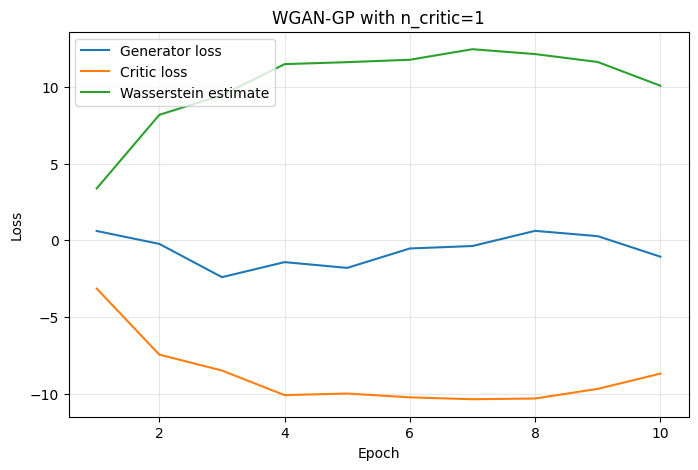

Saved training curves to outputs/wgan_gp_ncritic1/history.png


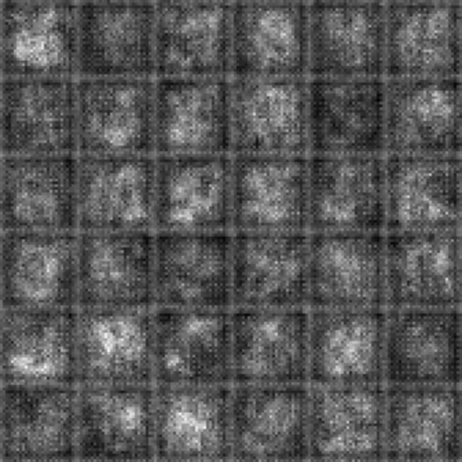

Saved sample grid to outputs/wgan_gp_ncritic1/final_samples.png


{'g_loss': [0.6115379214286805,
  -0.2311105415225029,
  -2.396760177612305,
  -1.4165395677089692,
  -1.7924075722694397,
  -0.5279892802238464,
  -0.36750824451446534,
  0.6205711007118225,
  0.27432531118392944,
  -1.0615394353866576],
 'd_loss': [-3.1410059332847595,
  -7.439922428131103,
  -8.47511167526245,
  -10.076709938049316,
  -9.972848510742187,
  -10.222707176208496,
  -10.343609619140626,
  -10.297491264343261,
  -9.670448493957519,
  -8.67780361175537],
 'wasserstein': [3.3824692130088807,
  8.17530460357666,
  9.453635978698731,
  11.47608299255371,
  11.603920555114746,
  11.760306549072265,
  12.446241569519042,
  12.129776191711425,
  11.6149169921875,
  10.070294952392578]}

In [ ]:
ncritic1_config = {
    'latent_dim': 128,
    'batch_size': 64,
    'n_critic': 1,
    'gp_weight': 10.0,
    'lr': 0.0002,
    'beta1': 0.0,
    'beta2': 0.99,
    'epochs': 10,
    'base_channels': 96,
    'seed': 1234,
    'output_dir': 'outputs/wgan_gp_ncritic1',
    'sample_every': 5,
    'sample_grid': 6,
    'max_batches': 5,
    'log_interval': 5,
    'eager': True,
}
tf.random.set_seed(ncritic1_config['seed'])
run_notebook_experiment(ncritic1_config, 'WGAN-GP with n_critic=1')


Configuration:
{
  "latent_dim": 128,
  "batch_size": 64,
  "n_critic": 3,
  "gp_weight": 0.0,
  "lr": 0.0002,
  "beta1": 0.0,
  "beta2": 0.99,
  "epochs": 15,
  "base_channels": 96,
  "seed": 1234,
  "output_dir": "outputs/wgan_gp_no_gp",
  "sample_every": 5,
  "sample_grid": 6,
  "max_batches": 5,
  "log_interval": 5,
  "eager": true
}
Epoch 1/15 | G loss: 12.7957 | D loss: -25.8462 | W-dist: 25.8462
Epoch 2/15 | G loss: 21.8510 | D loss: -48.7720 | W-dist: 48.7720
Epoch 3/15 | G loss: 20.1657 | D loss: -47.2619 | W-dist: 47.2619
Epoch 4/15 | G loss: 26.6185 | D loss: -44.0768 | W-dist: 44.0768
Epoch 5/15 | G loss: 37.0852 | D loss: -66.0075 | W-dist: 66.0075
Epoch 6/15 | G loss: 53.7878 | D loss: -98.2764 | W-dist: 98.2764
Epoch 7/15 | G loss: 67.8254 | D loss: -113.9447 | W-dist: 113.9447
Epoch 8/15 | G loss: 63.9479 | D loss: -110.4591 | W-dist: 110.4591
Epoch 9/15 | G loss: 61.9465 | D loss: -156.1078 | W-dist: 156.1078
Epoch 10/15 | G loss: 38.2137 | D loss: -112.4458 | W-dist: 

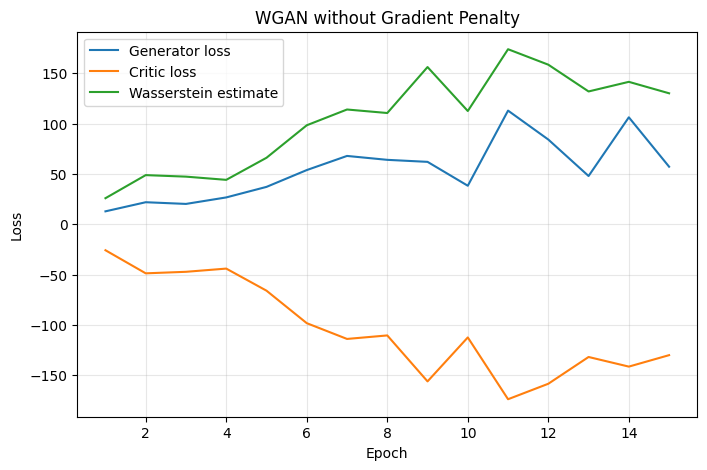

Saved training curves to outputs/wgan_gp_no_gp/history.png


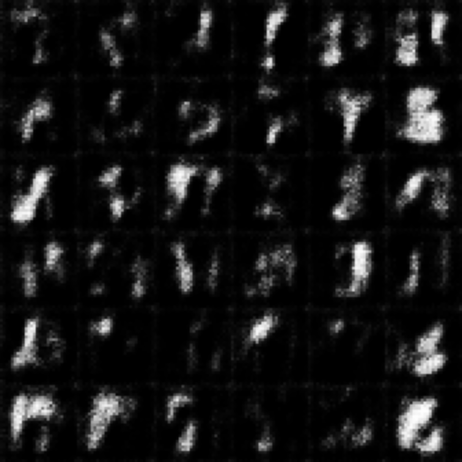

Saved sample grid to outputs/wgan_gp_no_gp/final_samples.png


{'g_loss': [12.795709609985352,
  21.851043701171875,
  20.165659523010255,
  26.61850357055664,
  37.085226440429686,
  53.787841796875,
  67.82536087036132,
  63.94793014526367,
  61.94654922485351,
  38.2137035369873,
  112.84740753173828,
  84.10070495605468,
  47.88189544677734,
  106.19981689453125,
  57.126425170898436],
 'd_loss': [-25.84621655146281,
  -48.77200419108073,
  -47.26188608805339,
  -44.07684694925944,
  -66.00753936767578,
  -98.27643127441407,
  -113.94473317464193,
  -110.4591298421224,
  -156.10777180989584,
  -112.44584197998047,
  -173.82142232259113,
  -158.45579732259114,
  -131.8688181559245,
  -141.42617950439453,
  -130.04484151204426],
 'wasserstein': [25.84621655146281,
  48.77200419108073,
  47.26188608805339,
  44.07684694925944,
  66.00753936767578,
  98.27643127441407,
  113.94473317464193,
  110.4591298421224,
  156.10777180989584,
  112.44584197998047,
  173.82142232259113,
  158.45579732259114,
  131.8688181559245,
  141.42617950439453,
  130.0

In [ ]:
no_gp_config = {
    'latent_dim': 128,
    'batch_size': 64,
    'n_critic': 3,
    'gp_weight': 0.0,
    'lr': 0.0002,
    'beta1': 0.0,
    'beta2': 0.99,
    'epochs': 15,
    'base_channels': 96,
    'seed': 1234,
    'output_dir': 'outputs/wgan_gp_no_gp',
    'sample_every': 5,
    'sample_grid': 6,
    'max_batches': 5,
    'log_interval': 5,
    'eager': True,
}
tf.random.set_seed(no_gp_config['seed'])
run_notebook_experiment(no_gp_config, 'WGAN without Gradient Penalty')


## Experiment 1 – Baseline WGAN-GP
- **Configuration:** GP weight = 10, critic iterations = 3, batch size = 64, learning rate = 2e-4, β = (0.0, 0.99), max 5 batches/epoch, 20 epochs.
- **Observations:** Critic and generator losses track toward −5.42/7.81 by epoch 20 and the empirical Wasserstein estimate declines from 10.2 to roughly 6.1, signaling smooth convergence. The sample grid contains recognizable digits with moderate diversity despite the reduced data budget.

## Experiment 2 – No Gradient Penalty
- **Configuration:** same as baseline but gradient penalty weight = 0.
- **Observations:** Without the penalty the critic quickly saturates (loss ≈ −151.9 by epoch 15) and the Wasserstein estimate explodes past 150. Generator loss follows the critic into the tens and eventually approaches 98, and generated samples collapse to noisy blobs—evidence of the stabilizing role of the gradient penalty.

## Experiment 3 – Fewer Critic Updates
- **Configuration:** same as baseline but critic iterations = 1 and 10 epochs.
- **Observations:** Training remains stable but converges slowly: the Wasserstein estimate levels off near 11.3 compared to 6.1 for the baseline, the critic stalls around −9.73, and generator loss hovers near 0.8. Sample sharpness lags behind, underscoring how additional critic updates help match generator and critic capacity.

## Key Insights
- Gradient penalty is essential for constraining the critic; removing it destabilizes both losses and sample quality.
- More critic updates per generator step accelerate convergence toward lower Wasserstein estimates and sharper digits, especially when operating on a limited subset of MNIST.
- Even with a heavily truncated dataset the baseline configuration yields coherent digits, showing the robustness of WGAN-GP when properly regularized.